In [1]:
pip install networkx matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


Graph created with 49 nodes and 37 edges.


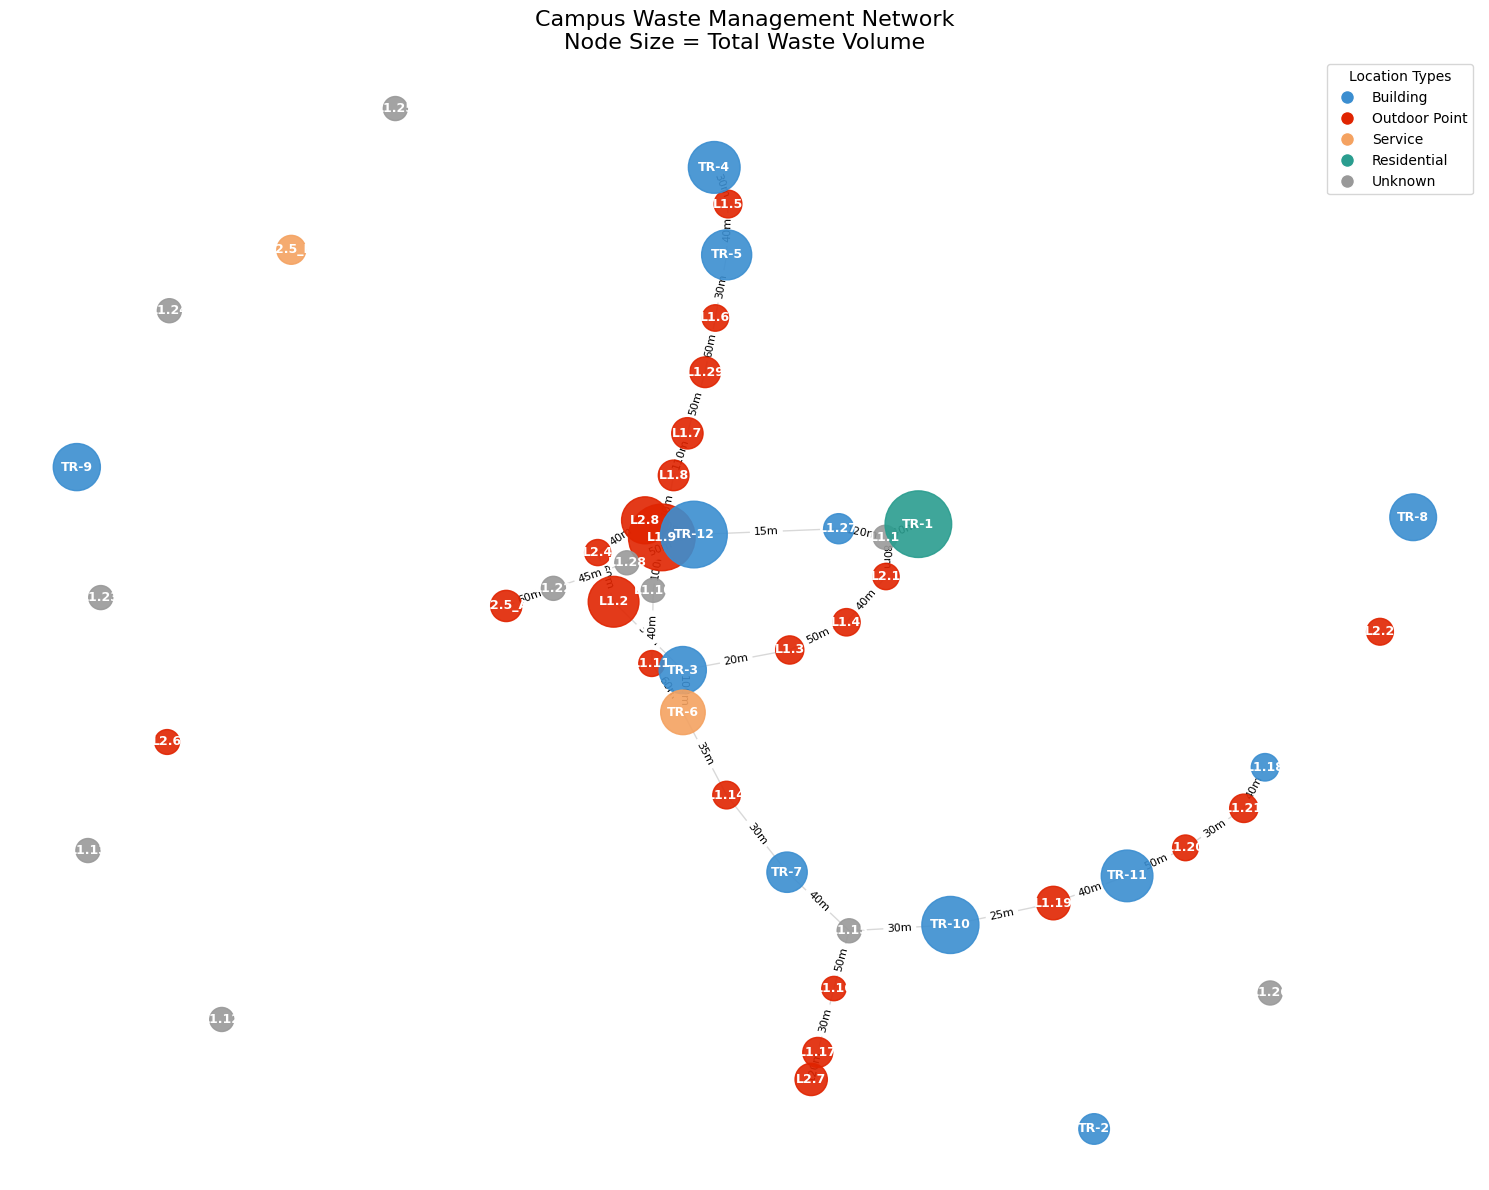

In [ ]:
import json
import csv
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# --- Configuration ---
OUTDOOR_FILE = './data/outdoor_trashbuffer.json'
BUILDING_FILE = './data/building_trashbuffer.json'
EDGES_FILE = './data/extracted_adjacent_travesal_path.csv'

def load_nodes(json_files):
    """Reads multiple JSON files and combines their node data."""
    combined_nodes = {}
    
    for file_path in json_files:
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                for node in data.get('nodes', []):
                    # Store key details: ID, Name, Type, and Total Waste
                    node_id = node['id']
                    combined_nodes[node_id] = {
                        'name': node.get('name_en', node_id),
                        'type': node.get('type', 'Unknown'),
                        'waste_total': node.get('waste', {}).get('total', 0)
                    }
        except FileNotFoundError:
            print(f"Warning: File {file_path} not found.")
            
    return combined_nodes

def create_waste_graph(nodes_data, edges_file):
    """Constructs a NetworkX graph from node dictionary and edges CSV."""
    G = nx.Graph()

    # 1. Add Nodes
    for node_id, attributes in nodes_data.items():
        G.add_node(node_id, **attributes)

    # 2. Add Edges from CSV
    try:
        edges_df = pd.read_csv(edges_file)
        for _, row in edges_df.iterrows():
            source, target = row['Source'], row['Target']
            weight = row['Weight']
            
            # Only add edge if both nodes exist in our JSON data
            # (Optional: Remove this check if you want to include nodes mentioned only in CSV)
            if source in nodes_data and target in nodes_data:
                G.add_edge(source, target, weight=weight)
            elif source in nodes_data or target in nodes_data:
                # Add the edge anyway to ensure connectivity, even if one node is a "waypoint"
                G.add_edge(source, target, weight=weight)
                
    except FileNotFoundError:
        print(f"Error: {edges_file} not found.")

    return G

def visualize_graph(G):
    """Draws the graph with color-coding and dynamic sizing."""
    plt.figure(figsize=(15, 12))

    # --- Layout ---
    # spring_layout uses the 'weight' (distance) to pull connected nodes closer
    pos = nx.spring_layout(G, weight='weight', seed=42, k=0.3, iterations=50)

    # --- Node Styling ---
    # Define colors for different node types
    color_map = []
    size_map = []
    
    type_colors = {
        'Building': '#3b8ed0',    # Blue
        'Outdoor Point': '#e02401', # Red
        'Service': '#f4a261',       # Orange
        'Residential': '#2a9d8f',   # Teal
        'Unknown': '#999999'        # Grey
    }

    for node in G.nodes():
        node_type = G.nodes[node].get('type', 'Unknown')
        waste_amt = G.nodes[node].get('waste_total', 0)
        
        # Color based on type
        color_map.append(type_colors.get(node_type, '#999999'))
        
        # Size based on waste amount (Base size 300 + scaled waste)
        # We limit the max size to prevent giant nodes covering the map
        size_map.append(300 + min(waste_amt * 0.5, 2000))

    # --- Drawing ---
    
    # Draw Edges
    nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray')
    
    # Draw Edge Labels (Distances)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    # Simplifies labels to just integers
    edge_labels = {k: f"{int(v)}m" for k, v in edge_labels.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=size_map, alpha=0.9)

    # Draw Node Labels (ID)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold", font_color="white")

    # --- Legend & Title ---
    # Create a custom legend
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', label=k,
                              markerfacecolor=v, markersize=10) for k, v in type_colors.items()]
    
    plt.legend(handles=legend_elements, loc='upper right', title="Location Types")
    plt.title("Campus Waste Management Network\nNode Size = Total Waste Volume", fontsize=16)
    plt.axis('off') # Turn off the axis numbers
    plt.tight_layout()
    plt.show()

# --- Main Execution ---
if __name__ == "__main__":
    # 1. Load Data
    all_nodes = load_nodes([OUTDOOR_FILE, BUILDING_FILE])
    
    # 2. Build Graph
    graph = create_waste_graph(all_nodes, EDGES_FILE)
    
    # 3. Visualize
    print(f"Graph created with {graph.number_of_nodes()} nodes and {graph.number_of_edges()} edges.")
    visualize_graph(graph)